In [1]:
import os

# Remove conda library overrides that break TeX
os.environ.pop("LD_LIBRARY_PATH", None)

# Avoid broken system TeX trees causing permission issues
os.environ["TEXMFHOME"] = os.path.expanduser("/usr/share/texlive/texmf-dist")
os.environ["TEXMFLOCAL"] = ""


import numpy as np
import matplotlib.pyplot as plt
import os
import tqdm
from scipy.interpolate import interp1d
import warnings
import matplotlib.cm as col
warnings.filterwarnings("ignore")

In [2]:
max_err=0.2
ylim_max = 17
colormap_normal = col.get_cmap("viridis")

S = 20000
B = 312858

plt.rcParams['pgf.rcfonts'] = False
#plt.rcParams['font.serif'] = []
plt.rcParams['font.family'] = "serif"
plt.rcParams['text.usetex'] = True
plt.rcParams['figure.figsize'] = 3, 2.4 #6.1, 2.2
plt.rcParams['axes.formatter.useoffset'] = False
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['errorbar.capsize'] = 2
plt.rcParams['grid.linewidth'] = 0.5
plt.rcParams['axes.labelsize'] = 9
plt.rcParams['axes.titlesize'] = 10 
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.title_fontsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.frameon'] = False

mode_colors = {"IAD": "black", "cathode": "orange", "cwola": "dodgerblue", "lacathode": "red"}
mode_name = {"IAD": "IAD", "cathode": "CATHODE", "cwola": "CWoLa Hunting", "lacathode": "LaCATHODE"}
inputset_name = {"baseline": "Baseline", "DeltaR": r"Baseline+$\Delta R$"}

recalculate_anyway = False

points = np.array([])


signals = [0,1000]
sig_plot = np.arange(0,1100,100)

plot_all=False

directory = "/hpcwork/p0025242/weak_supervision_domain_adaptation/domain_weight"

# Plotting Functions

In [3]:
def chi2_function(data, original, eff, plot=False, outpath=None):
    """
    calculates Chi2/dof between the original mjj-distribution and the one remaining after the cut. The general aproach is taken from https://arxiv.org/pdf/2210.14924. In their code they compute the normalization slightly differently, which probably should be looked into.
    Args:
        data (array): mjj values after cut
        original (array): total mjj distribution
        eff (float): selection efficiency (between 0 and 1)
        plot (bool): option to save and generate a plot
        outpath (str): path for the saved plot
    """
    n_bins = 300
    bins = np.quantile(original, np.linspace(0, 1, n_bins + 1))

    bkg, _ = np.histogram(original, bins=bins)
    top1, _ = np.histogram(data, bins=bins)

    bkg_normalized = bkg / np.sum(original)
    top1_normalized = top1 / np.sum(data)

    a = bkg_normalized / np.maximum(bkg, 1)  
    sigma2 = np.square(a) / eff * bkg * (1 - eff)

    pull = np.square(top1_normalized - bkg_normalized)
    dof = n_bins - 1

    return np.sum(pull / sigma2) / dof

def chi2_plot(m_jj_descending, m_jj):
    """
    calculates Chi2/dof for a range of selection efficiencies(fraction of mjj remaining after cut in score).
    Args:
        m_jj_descending (array): mjj sorted by score
        m_jj (array): entire mjj distribution
    Returns:
        effs (array), chi2_dofs (array)
    """
    selection_efficiencies = np.arange(0.01, 0.21, 0.01)[::-1]
    cutoff = (len(m_jj_descending) * selection_efficiencies).astype(int)

    chi2_dof = np.array([
        chi2_function(m_jj_descending[:cutoff_i], m_jj, eff=selection_efficiencies[i])
        for i, cutoff_i in enumerate(cutoff)
    ])
    #print(chi2_dof)
    return selection_efficiencies, chi2_dof

def calculate_chi2(folder, name="val_loss", runs=10, recalculate_anyway=False, sculpting_spectrum=True):
    if not os.path.exists(folder+f"{name}_chi2.npy") or recalculate_anyway:
        if os.path.exists(folder+"sculpting_masses.npy"):
            masses = np.load(folder+"sculpting_masses.npy")
        chi2 = np.zeros((runs, 20))
        for run in tqdm.tqdm(range(runs)):
            if not os.path.exists(folder+"sculpting_masses.npy"):
                masses = np.load(folder+f"sculpting_masses_run{run}.npy")
            scores = np.load(folder+f"run{run}/sculpting_{name}_preds.npy")
            sorted_indices = np.argsort(-scores)
            sorted_masses = masses[sorted_indices]
            efficiencies, chi2[run] = chi2_plot(sorted_masses, masses)
        np.save(folder+f"selection_efficiencies.npy", efficiencies)
        np.save(folder+f"{name}_chi2.npy", chi2)
        if sculpting_spectrum:
            spectrum = sorted_masses[:int(len(sorted_masses)*0.01)]
            np.save(folder+f"sculpting_{name}_selected_masses.npy", spectrum)
            return efficiencies, chi2, masses, spectrum
        return efficiencies, chi2
    else:
        print("No calculation needed")
        eff = np.load(folder+f"selection_efficiencies.npy")
        chi2 = np.load(folder+f"{name}_chi2.npy")
        if sculpting_spectrum:
            if not os.path.exists(folder+"sculpting_masses.npy"):
                masses_full = np.load(folder+f"sculpting_masses_run0.npy")
            else:
                masses_full = np.load(folder+"sculpting_masses.npy")
            masses_selected = np.load(folder+f"sculpting_{name}_selected_masses.npy")
            return eff, chi2, masses_full, masses_selected
        else:
            return eff, chi2

def get_spectrum(folder, run =0, name ="val_sic"):
    if not os.path.exists(folder+"sculpting_masses.npy"):
        masses = np.load(folder+f"sculpting_masses_run{run}.npy")
    else:
        masses = np.load(folder+"sculpting_masses.npy")
    scores = np.load(folder+f"run{run}/sculpting_{name}_preds.npy")
    sorted_indices = np.argsort(-scores)
    sorted_masses = masses[sorted_indices]
    return masses, sorted_masses[:int(len(sorted_masses)*0.01)]

def plot_all_spectra(list_of_dictionaries, runs=10):
    fig1, ax1 = plt.subplots(2,5, figsize=(15,5), tight_layout=True)
    ax1 = ax1.flatten()
    for i,l in enumerate(list_of_dictionaries):
        for j in range(runs):
            masses, sculpted_masses = get_spectrum(l["folder"], run=j, name=l["name"])
            if i==0:
                _, bins, _ = ax1[j].hist(masses, bins=50, density=True, color="lightgrey")
            ax1[j].hist(sculpted_masses, bins=bins, density=True, histtype="step", color=l["color"], linestyle=l["linestyle"], label=l["label"], linewidth=2)
            ax1[j].set_xlabel("$m_{JJ}$ [TeV]")
            ax1[j].set_ylabel("Normalized events")        
            ax1[j].set_yscale("log")
            ax1[j].set_ylim(3e-5, 5)

def plot_chi2s_and_spectra(ax_chi, ax_spectrum, list_of_dictionaries, recalculate_anyway=False, errorband=True, title=None, name=None, runs=10, legend=True):
    """
    Dictionary must contain: 
    folder, color, name, linestyle, label
    """
    #fig, ax = plt.subplots(1,2, figsize=(14,5))
    for i,l in enumerate(list_of_dictionaries):
        #print(i, l)
        eff, chi2_arr, masses, sculpted_masses = calculate_chi2(l["folder"], name=l["name"], recalculate_anyway=recalculate_anyway, sculpting_spectrum=True, runs=runs)
        if i==0:
            _, bins, _ = ax_spectrum.hist(masses, bins=50, density=True, color="lightgrey")
        ax_chi.plot(eff, np.median(chi2_arr, axis=0), color=l["color"], linestyle=l["linestyle"], label=l["label"])
        if errorband:
            ax_chi.fill_between(eff, np.percentile(chi2_arr, 16, axis=0), np.percentile(chi2_arr, 84, axis=0), color=l["color"], alpha=0.2)
        else:
            for i in range(10):
                ax_chi.plot(eff, chi2_arr[i], color=l["color"], alpha=0.2)
        ax_spectrum.hist(sculpted_masses, bins=bins, density=True, histtype="step", color=l["color"], linestyle=l["linestyle"], label=l["label"], linewidth=2)
    ax_spectrum.set_xlabel("$m_{JJ}$ [TeV]")
    ax_spectrum.set_ylabel("Normalized events")        
    ax_spectrum.set_yscale("log")
    ax_spectrum.set_ylim(3e-5, 5)
    ax_chi.set_yscale("log")
    ax_chi.set_ylim(0.5,5e3)
    ax_chi.set_xlim(0.2,0.01)
    if legend:
        ax_chi.legend()

    if title is not None:
        ymin, ymax = ax_chi.get_ylim()
        xmin, xmax = ax_chi.get_xlim()
        a = 0.03
        ax_chi.text(xmin + a * (xmax-xmin), np.exp(np.log(ymin) + (1-a) *(np.log(ymax)-np.log(ymin))) , title, size=plt.rcParams['axes.labelsize'], color='black', horizontalalignment='left', verticalalignment='top')

    ax_chi.set_xlabel("Selection efficiency")
    ax_chi.set_ylabel(r"$\chi^2$/dof")
    #fig.savefig(f"plots/chi2_and_spectra_{name}.pdf", bbox_inches='tight')

In [4]:
def plot_1D_scan(ax_sic, list_of_dicts, signals, sig_plot, title=None):
	plt.figure()

	sic_all = np.zeros((len(signals),len(points)+2))
	sic_all_low = np.zeros((len(signals),len(points)+2))
	sic_all_upp = np.zeros((len(signals),len(points)+2))
	for l in list_of_dicts:
		for j,s in enumerate(signals):
			sic_all[j], sic_all_low[j], sic_all_upp[j] = read_ROC_SIC_1D(l["name"], points, l["folder"]+"Nsig_"+str(s)+"/")
		plot_sic(ax_sic, sic_all[:,-1], sic_all_low[:,-1], sic_all_upp[:,-1], signals, l["color"], l["label"], linestyle=l["linestyle"])
	plot_end_1D(ax_sic, sig_plot, "1D_scan_"+title, title)

def read_ROC_SIC_1D(path, points, folder, N_runs=10, start_runs=0):
	fpr=np.load(folder+"fpr_"+path+".npy")[start_runs:start_runs+N_runs]
	#print(fpr.shape)
	tpr=np.load(folder+"tpr_"+path+".npy")[start_runs:start_runs+N_runs]
	ROC_values = np.zeros((len(fpr),len(points)))
	SIC_values = np.zeros((len(fpr),len(points)+2))
	for j in range(len(ROC_values)):
		inds = np.nonzero(tpr[j])[0]
		t = tpr[j, inds]
		f = fpr[j, inds]
		ROC_values[j] = interp1d(f, 1/f)(points)
		SIC_values[j,:-2] = interp1d(f, t/np.sqrt(f))(points)
		SIC_values[j,-1] = np.nanmax(np.nan_to_num(t/np.sqrt(f), posinf=0),where= f>1/312858/max_err**2,initial=0)
		SIC_values[j,-2] = np.nanmax(np.nan_to_num(t/np.sqrt(f),posinf=0))
	return np.median(SIC_values,axis=0), np.percentile(SIC_values, 16, axis=0), np.percentile(SIC_values, 84, axis=0)

def plot_end_1D(ax_sic,sig, name, title=None): 

	ax_sic.set_ylim(0,ylim_max)
	"""
	if title is not None:
		ymin, ymax = plt.ylim()
		xmin, xmax = plt.xlim()
		a = 0.03
		plt.text(xmin + a * (xmax-xmin), ymin + (1-a) *(ymax-ymin) , title, size=plt.rcParams['axes.labelsize'], color='black', horizontalalignment='left', verticalalignment='top')
	"""
	#.legend(loc='lower right')
	ax_sic.set_ylabel(r"$\max\ \epsilon_S/\sqrt{\epsilon_B}$")
	ax_sic.set_xlabel(r"$N_{sig}$")
	ax_sic.set_xticks(sig)

def plot_sic(ax_sic, sic, sic_low, sic_upp, sig, color, label, linestyle="solid"):
	ax_sic.plot(sig, sic, color=color,label=label, linestyle=linestyle, marker='o')
	ax_sic.fill_between(sig, sic_low, sic_upp, alpha=0.2, facecolor=color)

In [5]:
def construct_folder_name(mode, input_set, w, DA, folder_end="_ensemble5_start50"):
    if DA:
        return directory+"_"+str(w)+folder_end+"/"+mode+"/"+input_set+"_DA/"
    else:
        return directory+"_None"+folder_end+"/"+mode+"/"+input_set+"/"

def make_all_weights_pick(mode, w, runs=10, select="val_SIC", recalculate_anyway=False, plot_all=False, folder_end_DA="_ensemble5_start50"):

    fig, ax = plt.subplots(3,2, figsize=(7,8), tight_layout=True)
    fig.suptitle(mode_name[mode], fontsize=plt.rcParams['axes.titlesize']+2)

    for i,input_set in enumerate(["baseline", "DeltaR"]):

        listofdicts=[
        {"folder": construct_folder_name(mode, input_set, w[i], False)+"Nsig_0/", "name": select, "label": "Without DA", "color": "black", "linestyle": "solid"},
        {"folder": construct_folder_name(mode, input_set, w[0][i], True)+"Nsig_0/", "name": select, "label": "Classification DA", "color": "dodgerblue", "linestyle": "solid"},
        {"folder": construct_folder_name(mode, input_set, w[1][i], True, folder_end_DA)+"Nsig_0/", "name": select, "label": "Regression DA", "color": "orange", "linestyle": "solid"},
        ]
        if mode=="cathode":
            listofdicts.append({"folder": construct_folder_name("lacathode", input_set, w[i], False)+"Nsig_0/", "name": select, "label": "LaCATHODE", "color": "red", "linestyle": "solid"})

        plot_chi2s_and_spectra(ax[0,i], ax[1,i],listofdicts, recalculate_anyway=recalculate_anyway, runs=runs, errorband=not plot_all, title=inputset_name[input_set], name=mode, legend= (i==0))
        plot_all_spectra(listofdicts, runs=runs)

        signals = [0,50,100,150,200,250,300,400,500,600,700,800,900,1000]
        signals_plots = [0,200, 400,600,800,1000]

        if select=="val_SIC":
            select_sic = "val_sic"
        else: 
            select_sic = select
            
        listofdicts=[
            {"folder": construct_folder_name(mode, input_set, w[0][i], False), "name": select_sic, "label": "Without DA", "color": "black", "linestyle": "solid"},
            {"folder": construct_folder_name(mode, input_set, w[0][i], True), "name": select_sic, "label": "With DA", "color": "dodgerblue", "linestyle": "solid"},
            {"folder": construct_folder_name(mode, input_set, w[1][i], True, folder_end_DA), "name": select_sic, "label": "With DA", "color": "orange", "linestyle": "solid"},
            ]

        if mode=="cathode":
            listofdicts.append({"folder": construct_folder_name("lacathode", input_set, w[i], False), "name": select_sic, "label": "LaCATHODE", "color": "red", "linestyle": "solid"})

        plot_1D_scan(ax[2,i], listofdicts, signals, signals_plots, title=inputset_name[input_set])

    fig.savefig("plots/paper_plot_full_"+mode+".pdf")

No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed


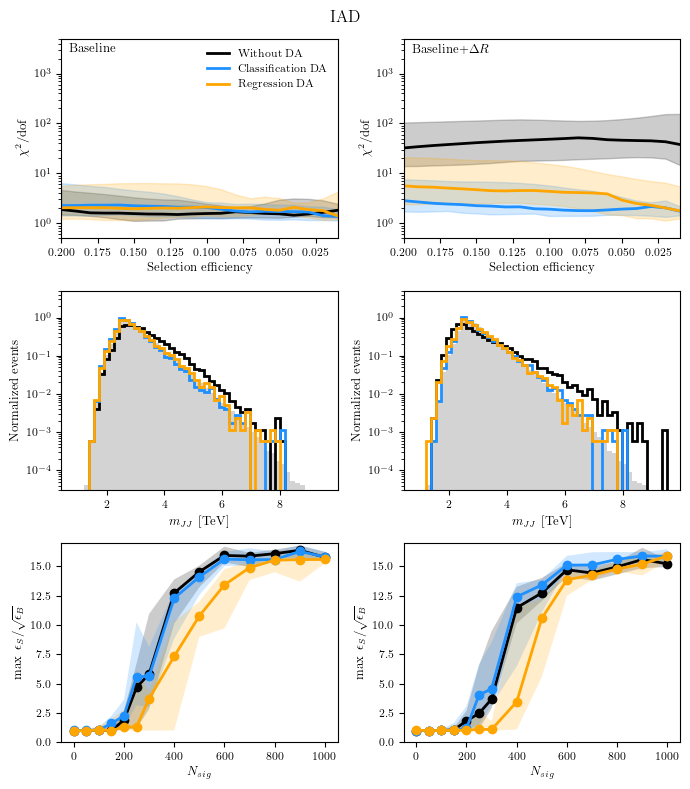

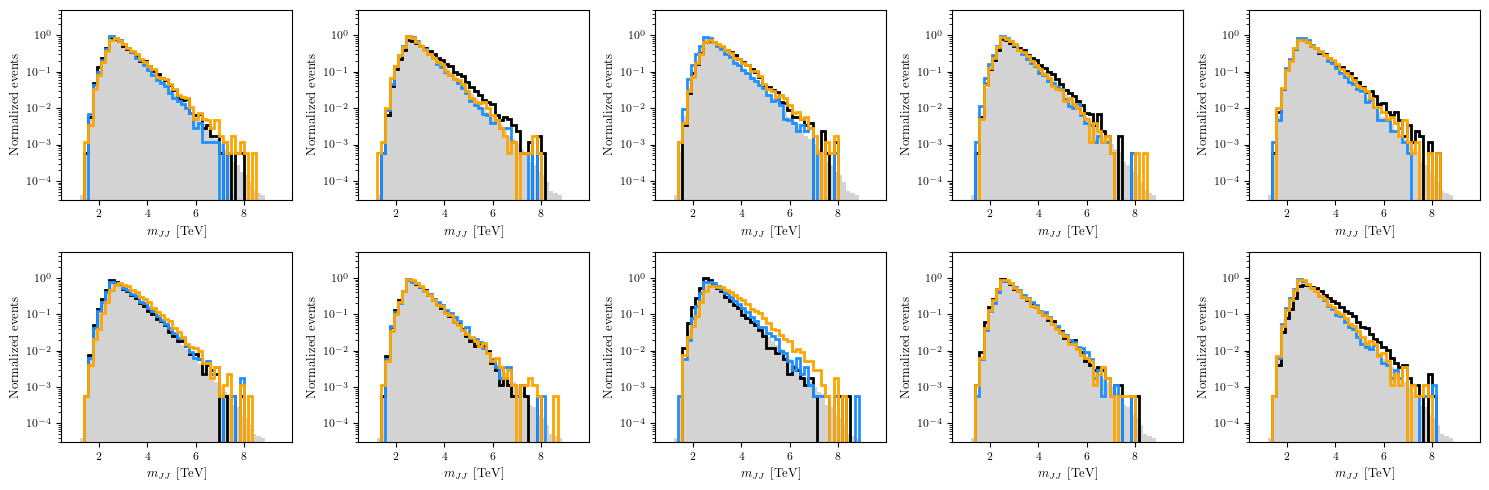

<Figure size 300x240 with 0 Axes>

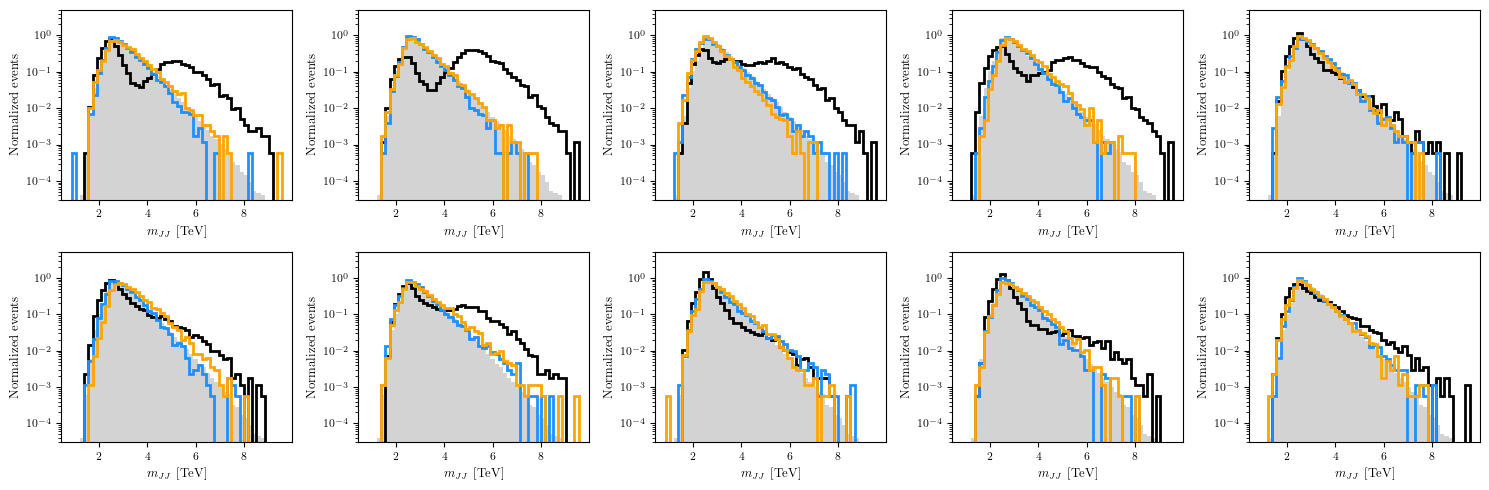

<Figure size 300x240 with 0 Axes>

In [37]:
make_all_weights_pick("IAD", [[0.1,0.1],[0.2, 0.2]], folder_end_DA="_regressions_ensemble5_start50")

No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed


/usr/share/texlive/texmf-local/texmf-compat/tex/latex/html/MM_BAK/ls-r: Permission denied
/usr/share/texlive/texmf-local/texmf-compat/tex/latex/html/MM_BAK/ls-R: Permission denied
/usr/share/texlive/texmf-local/texmf-compat/tex/latex/html/MM_BAK/aliases: Permission denied


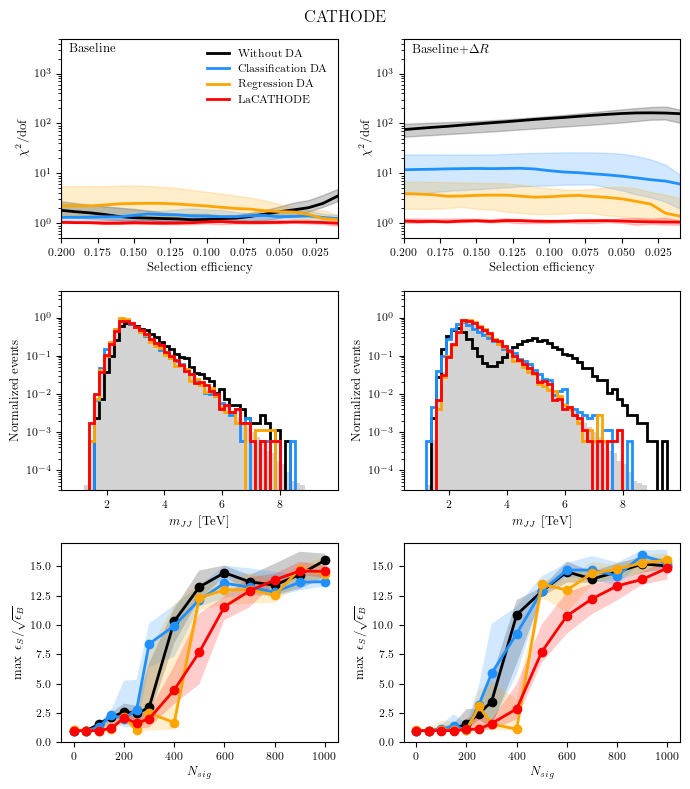

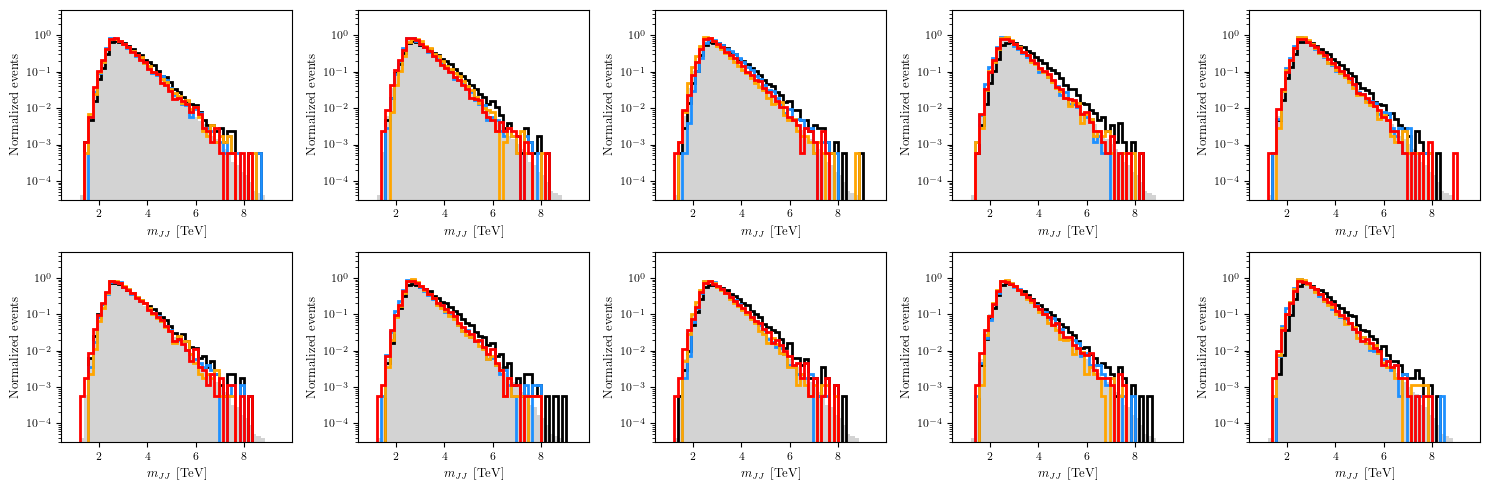

<Figure size 300x240 with 0 Axes>

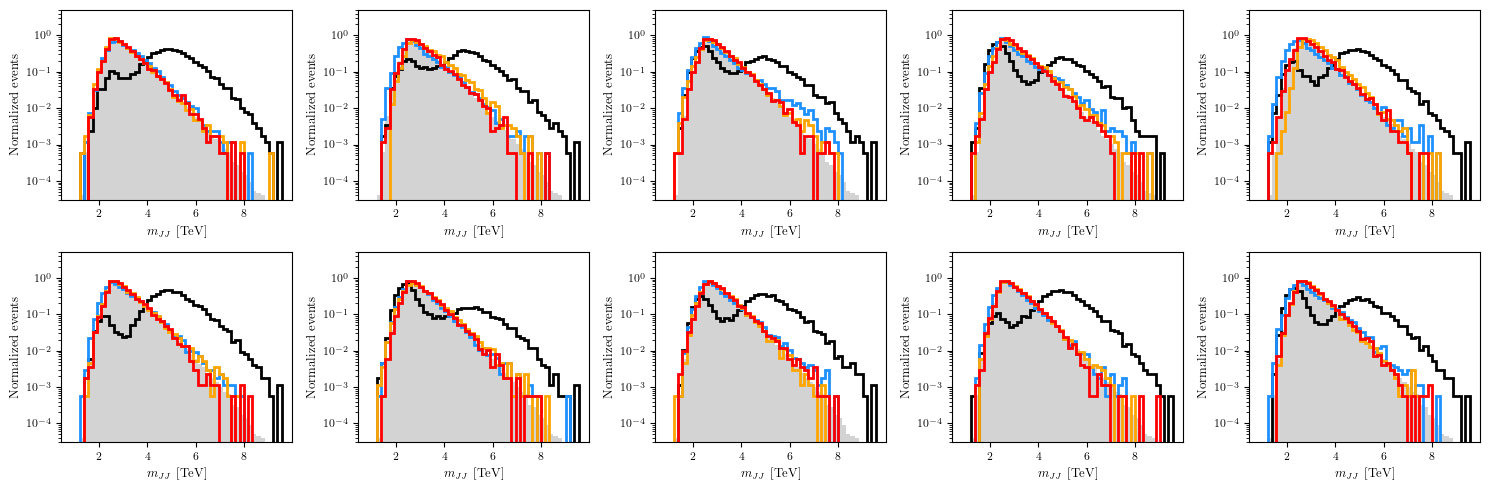

<Figure size 300x240 with 0 Axes>

In [6]:
make_all_weights_pick("cathode", [[0.1,0.1],[0.2, 0.2]],runs=10, folder_end_DA="_regressions_ensemble5_start50")

No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed


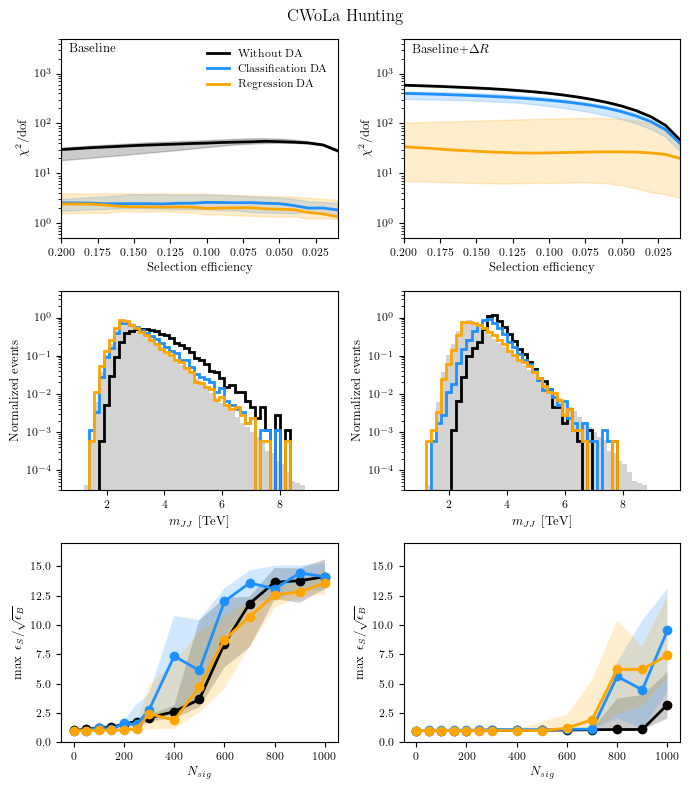

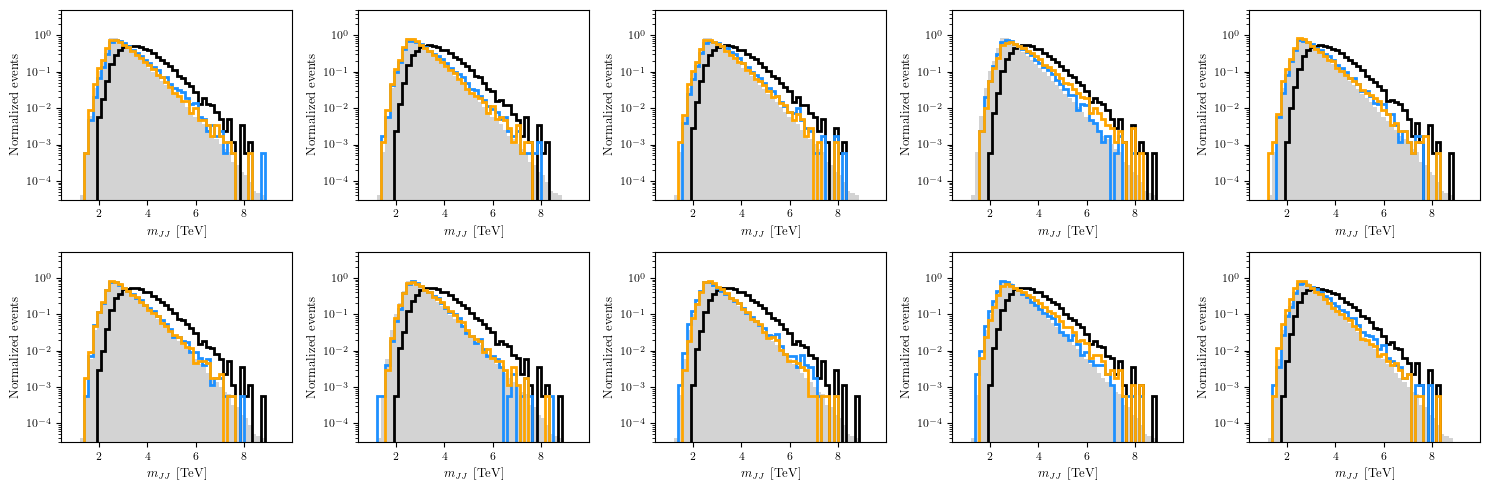

<Figure size 300x240 with 0 Axes>

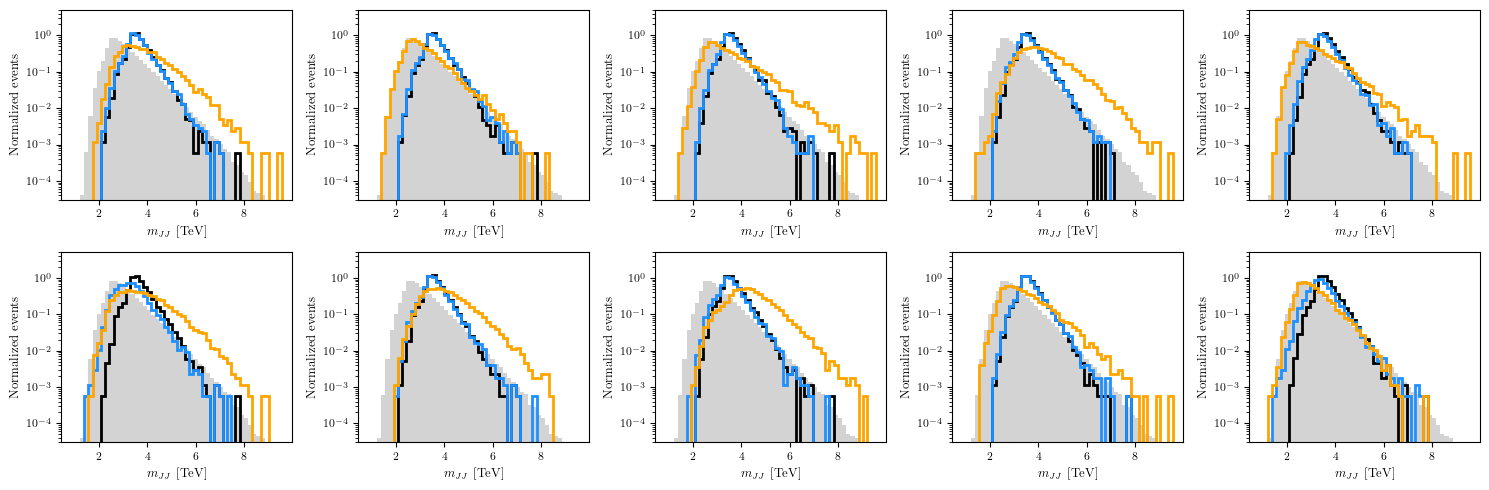

<Figure size 300x240 with 0 Axes>

In [40]:
make_all_weights_pick("cwola", [[0.4,1.5],[0.2, 2]], folder_end_DA="_regressions_ensemble5_start50")

In [32]:
def mean_and_percentiles(x_arrays,y_arrays,number=1000):
	x_values = np.linspace(0.01,1,number)
	y_values = np.zeros((len(y_arrays),len(x_values)))
	for j in range(len(y_arrays)):	
		y_values[j] = interp1d(x_arrays[j], y_arrays[j])(x_values)
	py = 1/y_values	
	y_mean = np.median(py,axis=0)
	#inds = np.argwhere(1/(x_values*S)+y_mean/B/4<0.2**2)[:,0]
	inds = np.argwhere(y_mean < 312858*max_err**2)[:,0]
	y_max = np.percentile(py,84,axis=0) 
	y_min = np.percentile(py,16,axis=0)
	return x_values[inds], y_mean[inds], y_min[inds], y_max[inds]

def plot_fn(ax,tpr,fpr,color,label, linestyle, alpha=0.2):
    tpr_mean, fpr_mean, fpr_min, fpr_max= mean_and_percentiles(tpr,fpr)
    ax.plot(tpr_mean, tpr_mean*np.sqrt(fpr_mean), color=color,label=label, linestyle=linestyle)    
    ax.fill_between(tpr_mean, tpr_mean*np.sqrt(fpr_min), tpr_mean*np.sqrt(fpr_max), alpha=alpha, facecolor=color)

def import_and_plot(ax, path, label=None, color="grey", folder="rocs/", N_runs =10, start_runs =0, alpha=0.2, linestyle='solid'):	
	#if label is None: 
	#	label=path
	fpr=np.load(folder+"fpr_"+path+".npy")[start_runs:start_runs+N_runs]
	#print(fpr.shape)
	tpr=np.load(folder+"tpr_"+path+".npy")[start_runs:start_runs+N_runs]
	plot_fn(ax, tpr,fpr,color,label, linestyle, alpha=alpha)
	return tpr,fpr

def plot_sics(ax, list_of_dicts):
	for l in list_of_dicts:
		name_use = "val_sic" if l["name"]=="val_SIC" else l["name"]
		import_and_plot(ax, name_use, label=l["label"], color=l["color"], linestyle=l["linestyle"], folder=l["folder"]+"Nsig_1000/")
	ax.set_xlim(0,1)#(-0.05,1.05)
	ax.set_ylim(0, ylim_max)
	ax.set_ylabel(r"$\epsilon_S/\sqrt{\epsilon_B}$")
	ax.set_xlabel(r"$\epsilon_S$")


def plot_chi2s_only(ax_chi, list_of_dictionaries, recalculate_anyway=False, errorband=True, title=None, name=None, runs=10, legend=True):
    """
    Dictionary must contain: 
    folder, color, name, linestyle, label
    """
    #fig, ax = plt.subplots(1,2, figsize=(14,5))
    for i,l in enumerate(list_of_dictionaries):
        #print(i, l)
        eff, chi2_arr = calculate_chi2(l["folder"]+"Nsig_0/", name=l["name"], sculpting_spectrum=False, runs=runs)
        ax_chi.plot(eff, np.median(chi2_arr, axis=0), color=l["color"], linestyle=l["linestyle"], label=l["label"])
        if errorband:
            ax_chi.fill_between(eff, np.percentile(chi2_arr, 16, axis=0), np.percentile(chi2_arr, 84, axis=0), color=l["color"], alpha=0.2)
        else:
            for i in range(10):
                ax_chi.plot(eff, chi2_arr[i], color=l["color"], alpha=0.2)
    ax_chi.set_yscale("log")
    ax_chi.set_ylim(0.5,5e3)
    ax_chi.set_xlim(0.2,0.01)
    if legend:
        ax_chi.legend()

    if title is not None:
        ymin, ymax = ax_chi.get_ylim()
        xmin, xmax = ax_chi.get_xlim()
        a = 0.03
        ax_chi.text(xmin + a * (xmax-xmin), np.exp(np.log(ymin) + (1-a) *(np.log(ymax)-np.log(ymin))) , title, size=plt.rcParams['axes.labelsize'], color='black', horizontalalignment='left', verticalalignment='top')

    ax_chi.set_xlabel("Selection efficiency")
    ax_chi.set_ylabel(r"$\chi^2$/dof")

No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed
No calculation needed


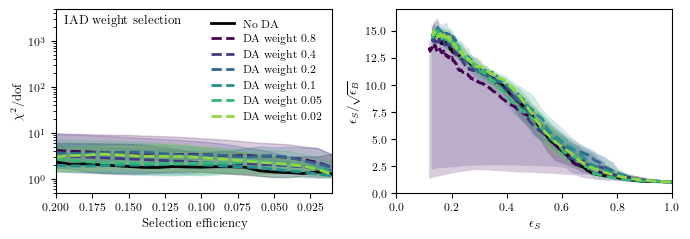

In [49]:
def construct_folder_name(mode, input_set, w, DA, folder_end="_ensemble5_start50"):
    if DA:
        return directory+"_"+str(w)+folder_end+"/"+mode+"/"+input_set+"_DA/"
    else:
        return directory+"_None"+folder_end+"/"+mode+"/"+input_set+"/"

def make_all_weights(mode, input_set, select, runs=10, recalculate_anyway=False, plot_all=False):

    fig, ax = plt.subplots(1,2, figsize=(7,2.5), tight_layout=True)
    listofdicts=[
    {"folder": construct_folder_name(mode, input_set, 0, False, folder_end=""), "name": select, "label": "No DA", "color": "black", "linestyle": "solid"},
    ]
    weights = [0.8, 0.4, 0.2, 0.1, 0.05, 0.02]

    for i,w in enumerate(weights):
        listofdicts.append({"folder": construct_folder_name(mode, input_set, w, True, folder_end=""), "name": select, "label": "DA weight "+str(w) , "color": 
                             colormap_normal(i/len(weights)), "linestyle": "dashed"})

    plot_chi2s_only(ax[0], listofdicts, title=mode_name[mode]+ " weight selection", name=mode)
    plot_sics(ax[1], listofdicts)
    fig.savefig("plots/weight_scan.pdf")

make_all_weights("IAD", "baseline","val_SIC", runs=10)

